In [11]:
# import os
# os.environ["OMP_NUM_THREADS"] = "1"
# os.environ["OPENBLAS_NUM_THREADS"] = "1"
# os.environ["MKL_NUM_THREADS"] = "1"
# os.environ["NUMEXPR_NUM_THREADS"] = "1"


In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.vq import kmeans2 

daily_metrics_file = '../src/data/processed/daily_metrics.csv'
daily_metrics = pd.read_csv(daily_metrics_file)

if 'Unnamed: 0' in daily_metrics.columns and 'date' not in daily_metrics.columns:
    daily_metrics.rename(columns={'Unnamed: 0': 'date'}, inplace=True)

daily_metrics['date'] = pd.to_datetime(daily_metrics['date'])
daily_metrics.sort_values(by='date', inplace=True)
daily_metrics.reset_index(drop=True, inplace=True)

features = [
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_std',
    'demand_National Demand Forecast (NDF) - GB (MW)_mean',
    'solar_solar_fc_meteo_mw_mean',
    'wind_wind_fc_meteo_mw_mean'
]

X = daily_metrics[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 10  
centroids, labels = kmeans2(X_scaled, n_clusters, minit='++')

daily_metrics['cluster'] = labels

print("Clustered Daily Metrics:")
print(daily_metrics[['date', 'cluster']].head())
print("\nCluster counts:")
print(daily_metrics['cluster'].value_counts())

output_file = '../src/data/processed/daily_metrics_with_clusters.csv'
daily_metrics.to_csv(output_file, index=False)
print(f"\nClustered data saved to {output_file}")


Clustered Daily Metrics:
        date  cluster
0 2024-05-31        5
1 2024-06-01        4
2 2024-06-02        4
3 2024-06-03        0
4 2024-06-04        5

Cluster counts:
cluster
0    28
3    24
5    22
4    22
9    16
1    13
8    12
7    10
2     4
6     2
Name: count, dtype: int64

Clustered data saved to ../src/data/processed/daily_metrics_with_clusters.csv


In [68]:
import pandas as pd
import numpy as np
from datetime import timedelta


daily_metrics = pd.read_csv('../src/data/processed/daily_metrics_with_clusters.csv')
daily_metrics['date'] = pd.to_datetime(daily_metrics['date'])

da_actuals = pd.read_csv('../src/data/processed/gb_epex_da_actuals.csv', parse_dates=['dtutc'])
da_actuals['date'] = da_actuals['dtutc'].dt.date
delivery_dates = np.unique(da_actuals['date'])

def find_reference_day(target_date, lookback=60):

    if not isinstance(target_date, pd.Timestamp):
        target_date = pd.Timestamp(target_date)
    
    target_info = daily_metrics[daily_metrics['date'] == target_date]
    if target_info.empty:
        return None
    
    target_cluster = target_info['cluster'].values[0]
    
    past_days = daily_metrics[
        (daily_metrics['date'] < target_date) & 
        (daily_metrics['date'] >= target_date - pd.Timedelta(days=lookback))
    ]
    
    if past_days.empty:
        return None
    
    same_cluster_days = past_days[past_days['cluster'] == target_cluster]
    
    if same_cluster_days.empty:
        return past_days.iloc[-1]['date'].date()
    
    return same_cluster_days.iloc[-1]['date'].date()

reference_mapping = {}

available_dates = daily_metrics['date'].dt.date.unique()
valid_delivery_dates = [d for d in delivery_dates if d in available_dates]

print(f"Total valid delivery dates: {len(valid_delivery_dates)}")

for del_date in valid_delivery_dates:
    target_date = pd.Timestamp(del_date)
    ref_day = find_reference_day(target_date, lookback=60)
    
    if ref_day is not None:
        reference_mapping[del_date] = ref_day
    else:
        fallback_date = (target_date - timedelta(days=1)).date()
        reference_mapping[del_date] = fallback_date
        print(f"Warning: No reference day found for {del_date}. Using {fallback_date} as fallback.")
reference_df = pd.DataFrame(list(reference_mapping.items()), columns=['delivery_date', 'reference_date'])

reference_df.to_csv('../src/data/processed/kmeans_reference_mapping.csv', index=False)

print(f"Reference day mapping saved to '../src/data/processed/kmeans_reference_mapping.csv'")

print(f"Total delivery dates mapped: {len(reference_mapping)}")


Total valid delivery dates: 153
Reference day mapping saved to '../src/data/processed/kmeans_reference_mapping.csv'
Total delivery dates mapped: 153


In [65]:
ref_days= pd.read_csv('../src/data/processed/kmeans_reference_mapping.csv')
ref_days.head()

,delivery_date,reference_date
0,2024-05-31,2024-05-30
1,2024-06-01,2024-05-31
2,2024-06-02,2024-06-01
3,2024-06-03,2024-06-02
4,2024-06-04,2024-05-31


In [67]:
ref_days.tail()

,delivery_date,reference_date
148,2024-10-26,2024-10-25
149,2024-10-27,2024-10-19
150,2024-10-28,2024-10-24
151,2024-10-29,2024-10-26
152,2024-10-30,2024-10-29


Daily Metrics Sample:
        date  demand_National Demand Forecast (NDF) - GB (MW)_mean  \
0 2024-05-31                                       19731.500000      
1 2024-06-01                                       20013.333333      
2 2024-06-02                                       18956.500000      
3 2024-06-03                                       23517.583333      
4 2024-06-04                                       23226.458333      

   demand_National Demand Forecast (NDF) - GB (MW)_max  \
0                                            20098.0     
1                                            24200.0     
2                                            24718.5     
3                                            27674.5     
4                                            26778.0     

   demand_National Demand Forecast (NDF) - GB (MW)_min  \
0                                            19365.0     
1                                            17441.0     
2                                 

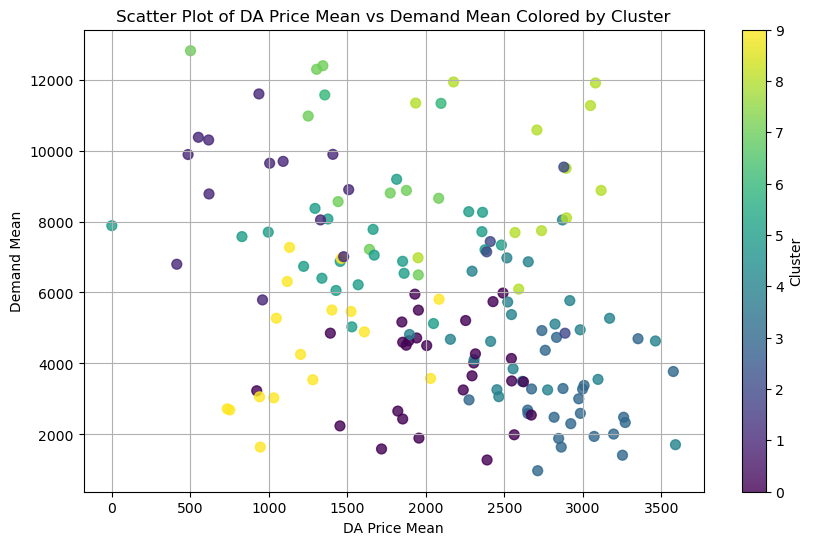

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

daily_metrics = pd.read_csv('../src/data/processed/daily_metrics_with_clusters.csv', parse_dates=['date'])
print("Daily Metrics Sample:")
print(daily_metrics.head())


solar_mean_col = 'solar_solar_fc_meteo_mw_mean'
wind_mean_col = 'wind_wind_fc_meteo_mw_mean'

plt.figure(figsize=(10, 6))
scatter = plt.scatter(daily_metrics[solar_mean_col],
                      daily_metrics[wind_mean_col],
                      c=daily_metrics['cluster'],
                      cmap='viridis',
                      s=50,
                      alpha=0.8)
plt.xlabel('DA Price Mean')
plt.ylabel('Demand Mean')
plt.title('Scatter Plot of DA Price Mean vs Demand Mean Colored by Cluster')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()




Reference Mapping Sample (Filtered):
  delivery_date reference_date
0    2024-05-31     2024-05-30
1    2024-06-01     2024-05-31
2    2024-06-02     2024-06-01
3    2024-06-03     2024-06-02
4    2024-06-04     2024-05-31
Total filtered dates: 153


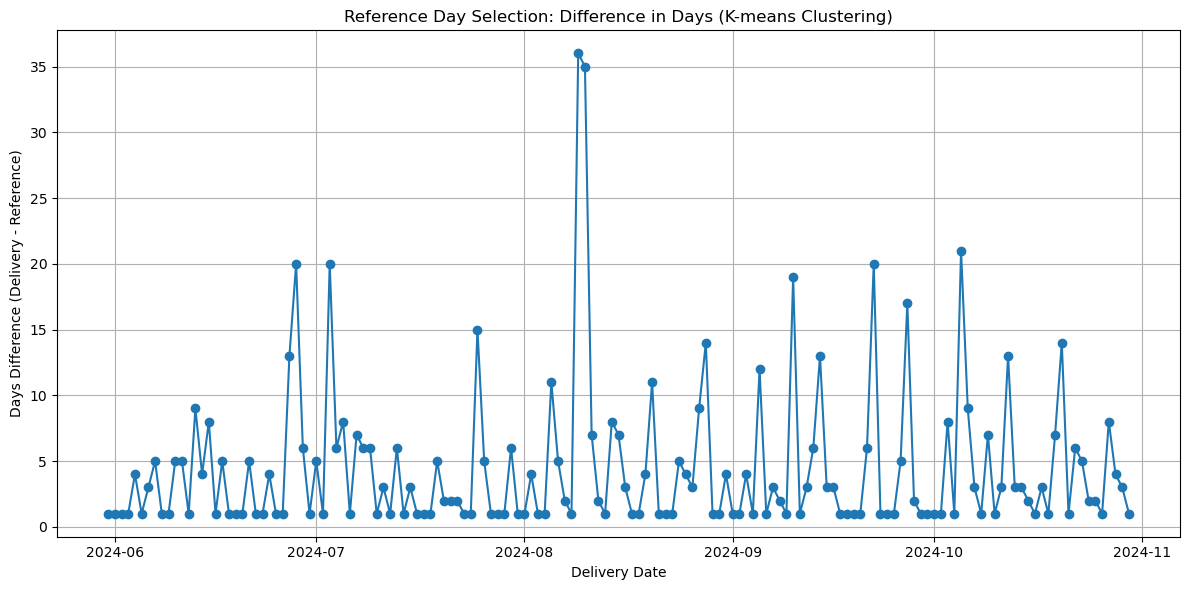

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

reference_mapping_file = '../src/data/processed/kmeans_reference_mapping.csv'
reference_mapping = pd.read_csv(reference_mapping_file, parse_dates=['delivery_date', 'reference_date'])

daily_metrics = pd.read_csv('../src/data/processed/daily_metrics_with_clusters.csv')
daily_metrics['date'] = pd.to_datetime(daily_metrics['date'])
available_dates = daily_metrics['date'].dt.date

reference_mapping_filtered = reference_mapping[reference_mapping['delivery_date'].dt.date.isin(available_dates)]

print("\nReference Mapping Sample (Filtered):")
print(reference_mapping_filtered.head())
print(f"Total filtered dates: {len(reference_mapping_filtered)}")

reference_mapping_filtered['days_difference'] = (reference_mapping_filtered['delivery_date'] - reference_mapping_filtered['reference_date']).dt.days

plt.figure(figsize=(12, 6))
plt.plot(reference_mapping_filtered['delivery_date'],
         reference_mapping_filtered['days_difference'],
         marker='o',
         linestyle='-',
         color='tab:blue')
plt.xlabel('Delivery Date')
plt.ylabel('Days Difference (Delivery - Reference)')
plt.title('Reference Day Selection: Difference in Days (K-means Clustering)')
plt.grid(True)
plt.tight_layout()
plt.show()


Using sklearn for clustering 

In [44]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans  

daily_metrics_file = '../src/data/processed/daily_metrics.csv'
daily_metrics = pd.read_csv(daily_metrics_file)



In [49]:
print(daily_metrics.columns)

Index(['date', 'demand_National Demand Forecast (NDF) - GB (MW)_mean',
       'demand_National Demand Forecast (NDF) - GB (MW)_max',
       'demand_National Demand Forecast (NDF) - GB (MW)_min',
       'demand_National Demand Forecast (NDF) - GB (MW)_spread',
       'demand_National Demand Forecast (NDF) - GB (MW)_std',
       'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean',
       'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_max',
       'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_min',
       'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_spread',
       'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_std',
       'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_rolling_std_7d',
       'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_price_range',
       'price_Price average forecast ECMWF ENS United

In [45]:
if 'Unnamed: 0' in daily_metrics.columns and 'date' not in daily_metrics.columns:
    daily_metrics.rename(columns={'Unnamed: 0': 'date'}, inplace=True)

daily_metrics['date'] = pd.to_datetime(daily_metrics['date'])
daily_metrics.sort_values(by='date', inplace=True)
daily_metrics.reset_index(drop=True, inplace=True)

features = [
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_std',
    'demand_National Demand Forecast (NDF) - GB (MW)_mean',
    'solar_solar_fc_meteo_mw_mean',
    'wind_wind_fc_meteo_mw_mean'
]



In [46]:

missing_cols = [col for col in features if col not in daily_metrics.columns]
if missing_cols:
    raise ValueError(f"Missing columns in CSV: {missing_cols}")




In [47]:

X = daily_metrics[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [48]:

n_clusters = 10  
if len(X_scaled) < n_clusters:
    n_clusters = len(X_scaled)  

kmeans = KMeans(n_clusters=n_clusters, init="random", random_state=42, n_init=10)
daily_metrics['cluster'] = kmeans.fit_predict(X_scaled)



AttributeError: 'NoneType' object has no attribute 'split'

In [ ]:
print("Clustered Daily Metrics:")
print(daily_metrics[['date', 'cluster']].head())
print("\nCluster counts:")
print(daily_metrics['cluster'].value_counts())

output_file = '../src/data/processed/daily_metrics_with_clusters.csv'
daily_metrics.to_csv(output_file, index=False)
print(f"\nClustered data saved to {output_file}")

In [38]:
import sklearn
import sys
print("Python version:", sys.version)
print("Scikit-learn version:", sklearn.__version__)


Python version: 3.11.4 | packaged by Anaconda, Inc. | (main, Jul  5 2023, 13:38:37) [MSC v.1916 64 bit (AMD64)]
Scikit-learn version: 1.3.1
